In [2]:
import pandas as pd
import numpy as np
data=pd.read_csv("laptop_price - dataset.csv")
df=pd.DataFrame(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-null   object 
 11  GPU_Type             1275 non-null   object 
 12  OpSys                1275 non-null   object 
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), int64(1), object(10)
me

In [3]:
df.describe()

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,2.302980,8.440784,2.040525,1134.969059
std,1.429470,0.503846,5.097809,0.669196,700.752504
min,10.100000,0.900000,2.000000,0.690000,174.000000
25%,14.000000,2.000000,4.000000,1.500000,609.000000
50%,15.600000,2.500000,8.000000,2.040000,989.000000
75%,15.600000,2.700000,8.000000,2.310000,1496.500000
max,18.400000,3.600000,64.000000,4.700000,6099.000000


In [4]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [5]:
# This shows how much each number relates to the price
# 1.0 is perfect correlation, 0 is no relation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
print(numeric_df.corr()['Price (Euro)'].sort_values(ascending=False))

Price (Euro)           1.000000
RAM (GB)               0.740287
CPU_Frequency (GHz)    0.428847
Weight (kg)            0.211883
Inches                 0.066608
Name: Price (Euro), dtype: float64


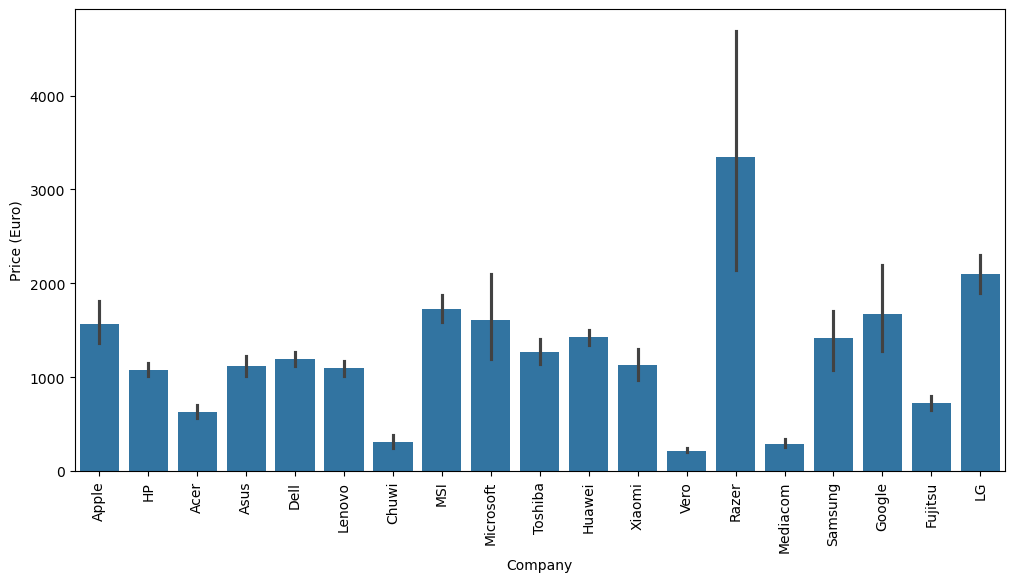

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x=df['Company'], y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

In [34]:
# 1. Split and take the last element for X (e.g., '1920')
# and the first element after the split for Y (e.g., '1080')
df['X_res'] = df['ScreenResolution'].apply(lambda x: x.split()[-1].split('x')[0]).astype(int)
df['Y_res'] = df['ScreenResolution'].apply(lambda x: x.split()[-1].split('x')[1]).astype(int)

# 2. Check the new columns
print(df[['ScreenResolution', 'X_res', 'Y_res']].head())

# 3. Now check the correlation again!
numeric_df = df.select_dtypes(include=['float64', 'int64'])
print(numeric_df.corr()['Price (Euro)'].sort_values(ascending=False))

                     ScreenResolution  X_res  Y_res
0  IPS Panel Retina Display 2560x1600   2560   1600
1                            1440x900   1440    900
2                   Full HD 1920x1080   1920   1080
3  IPS Panel Retina Display 2880x1800   2880   1800
4  IPS Panel Retina Display 2560x1600   2560   1600
Price (Euro)           1.000000
RAM (GB)               0.740287
X_res                  0.552491
Y_res                  0.548529
CPU_Frequency (GHz)    0.428847
Weight (kg)            0.211883
Inches                 0.066608
Name: Price (Euro), dtype: float64


In [36]:
# Extracting X and Y resolutions
df['X_res'] = df['ScreenResolution'].str.extract('(\d+)x').astype(int)
df['Y_res'] = df['ScreenResolution'].str.extract('x(\d+)').astype(int)

# Calculate Correlation again
numeric_df = df.select_dtypes(include=['float64', 'int64'])
print(numeric_df.corr()['Price (Euro)'].sort_values(ascending=False))

Price (Euro)           1.000000
RAM (GB)               0.740287
X_res                  0.552491
Y_res                  0.548529
CPU_Frequency (GHz)    0.428847
Weight (kg)            0.211883
Inches                 0.066608
Name: Price (Euro), dtype: float64


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.mode
# 1. Define your "Features" (X) and your "Target" (y)
X = df[['RAM (GB)', 'X_res', 'CPU_Frequency (GHz)']] 
y = df['Price (Euro)']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Multiple Linear Regression model
multi_model = LinearRegression().fit(X_train, y_train)

# 4. Check the new Score
print(f"Old Score (RAM only): {model.score(X_test[['RAM (GB)']], y_test)}") # If you kept the old model
print(f"New Score (Multi-Feature): {multi_model.score(X_test, y_test)}")

Prediction Accuracy (R2 Score): 0.5115066438876673
